# ICNPG 2019

Pablo Cappagli 
<pablocappagli@gmail.com>

# Introducción a Numpy

## 0. Links últiles:

https://docs.scipy.org/doc/numpy/user/quickstart.html

http://www.scipy-lectures.org/intro/numpy/index.html

## 1. Introducción

Habíamos visto que se pueden hacer 'secuencias' de elementos 1D, 2D, etc, a través de listas (o tuplas)

In [2]:
A =  [[ 1.0, 0.0, 0.0],[ 0.0, 1.0, 2.0]]

print(A)
print(type(A))
print(len(A))

[[1.0, 0.0, 0.0], [0.0, 1.0, 2.0]]
<class 'list'>
2


Sin embargo, la biblioteca ideal para trabajar con este tipo de arreglos (arrays), es Numpy

In [3]:
import numpy as np

A = np.array([[ 1.0, 0.0, 0.0], [ 0.0, 1.0, 2.0]])

print(A)
type(A)

[[1. 0. 0.]
 [0. 1. 2.]]


numpy.ndarray

donde el objeto array creado, tiene varios atributos (y métodos) asociados:

In [4]:
A.ndim

2

In [5]:
A.shape

(2, 3)

In [6]:
A.size

6

In [7]:
A.dtype

dtype('float64')

In [8]:
A.itemsize

8

Otro ejemplo (utilizando el iterador 'range' visto ateriormente):

In [9]:
B = np.array(range(15))
B

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [10]:
B = B.reshape(3, 5)
B

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [11]:
print('Cantidad de filas y columnas: ', B.shape)

print('Dimensiones: ', B.ndim)

print('Tipo de datos: ', B.dtype)

print('Cantidad de bytes por item: ', B.itemsize)

print('Cantidad de elementos en el array: ', B.size)

Cantidad de filas y columnas:  (3, 5)
Dimensiones:  2
Tipo de datos:  int32
Cantidad de bytes por item:  4
Cantidad de elementos en el array:  15


### 1.1 Creación de arrays

Un error común es tratar de crear el array con una secuencia de números, en lugar de usar una lista o una tupla

In [12]:
C = np.array(1,2,3,4)    # <---No


ValueError: only 2 non-keyword arguments accepted

In [13]:
C = np.array([1,2,3,4])  # <---Si
D = np.array((1,2,3,4))  # <---Si

print(D)


[1 2 3 4]


Con np.array() podemos transformar listas (o tuplas) en arrays 1D, listas de listas en arrays 2D, listas de listas de listas en arrays 3D, etc..

In [15]:
C = np.array([1,2,3,4])

print(C.shape)

E = np.array([[1,2,3,4], [1,2,3,4]])

print(E.shape)

F = np.array([[[1,2,3,4], [1,2,3,4]], [[1,2,3,4], [1,2,3,4]]])

print(F.shape)

(4,)
(2, 4)
(2, 2, 4)


También se puede definir el tipo al momento de creear el array

In [16]:
D = np.array([[1,2], [3,4]], dtype=np.float32)

print(D)
print(D.dtype)

[[1. 2.]
 [3. 4.]]
float32


o se puede hacer un cast luego de creado

In [17]:
D = D.astype(np.int32)

print(D)
print(D.dtype)

[[1 2]
 [3 4]]
int32


Pre-inicialización de arrays (alloc)

In [18]:
A = np.zeros((3,4))
print(A)

B = np.ones((3,4), dtype = np.int16) # se puede especificar el tipo
print(B)

C = np.empty((3,4)) # sin inicializar a un valor (el resultado puede variar)
print(C)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


Con "np.arange", se puede crear secuencias de números, al estilo de 'range', pero devolviendo directamente un array:

In [20]:
A = np.arange( 10, 30, 5 )
print(A)
print(type(A))

B = np.arange( 0, 2, 0.3 ) 
print(B)

[10 15 20 25]
<class 'numpy.ndarray'>
[0.  0.3 0.6 0.9 1.2 1.5 1.8]


Cuando se utiliza 'arange' con argumentos de punto flotante, generalmente no es posible predecir la cantidad de elementos obtenidos, debido a la precisión finita del punto flotante. Por esta razón, usualmente es mejor usar la función 'linspace' que recibe como argumento la cantidad de elementos que queremos, en lugar del paso:

In [21]:
np.linspace( 0, 2, 9 )                 # nueve números de 0 a 2

array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  ])

In [22]:
x = np.linspace( 0, 2*np.pi, 100)       # util para evaluar funciones en muchos puntos
f = np.sin(x)

print(x.shape)
print(f.shape)

(100,)
(100,)


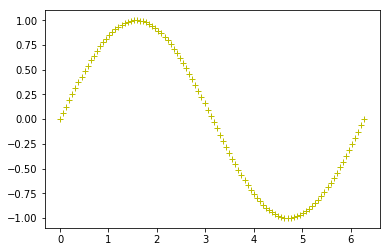

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(x, f, '+y')
plt.show()

### 1.2 Operaciones básicas

Los operadores aritméticos en arrays se aplican elemento a elemento:

In [25]:
A = np.array([20,30,40,50])
B = np.arange(4)

print('A =', A)
print('B =', B)

A = [20 30 40 50]
B = [0 1 2 3]


In [26]:
C = A - B
print('C =', C)

C = [20 29 38 47]


In [27]:
D = B**2

print('D =', D)

D = [0 1 4 9]


In [28]:
E = 10*np.sin(A)

print('E =', E)

E = [ 9.12945251 -9.88031624  7.4511316  -2.62374854]


In [29]:
F = A!=20

print('F =', F)

F = [False  True  True  True]


A diferencia de muchos lenguajes matriciales, el operador producto (*) opera elemento a elemento. 

(El producto matricial se puede realizar usando np.dot())

In [30]:
A = np.array([[1.0, 0.0], [0.0, 1.0]])

B = np.array([[2.0, 0.0], [3.0, 4.0]] )

C = A*B                         #<--- producto elemento a elemento

print(A)
print(B)
print(C)

[[1. 0.]
 [0. 1.]]
[[2. 0.]
 [3. 4.]]
[[2. 0.]
 [0. 4.]]


In [31]:
D = A.dot(B)                # <---- producto matricial

E = np.dot(A, B)                # <---- producto matricial

# print(A)
print(D)
print(E)


[[2. 0.]
 [3. 4.]]
[[2. 0.]
 [3. 4.]]


In [32]:
A = np.ones((2,3), dtype=np.int32)

A += 3


print(A)
print(A.dtype)

[[4 4 4]
 [4 4 4]]
int32


In [33]:
B = np.random.random((2,3))

print(B)
B += A

print(B)
print(B.dtype)

[[0.99057732 0.64637037 0.84609225]
 [0.28290481 0.17276958 0.43105273]]
[[4.99057732 4.64637037 4.84609225]
 [4.28290481 4.17276958 4.43105273]]
float64


In [34]:
A = B.astype(np.int32)         # B no se convierte a entero automaticamente, ni hay upcasting de A

print(A)
print(A.dtype)

[[4 4 4]
 [4 4 4]]
int32


Cuando se opera con arrays de diferentes tipos, el tipo de array resultante corresponde al más general o preciso (un comportamiento conocido como upcasting).

In [35]:
A = np.ones(3, dtype=np.int32)
B = np.linspace(0,np.pi,3)

print(A.dtype)
print(B.dtype)

C = A + B

print(C.dtype)




int32
float64
float64


In [36]:
D = np.exp(C*1j)

print(D)

[ 0.54030231+0.84147098j -0.84147098+0.54030231j -0.54030231-0.84147098j]


Muchas operaciones, como computar la suma de todos los elementos de un array, son métodos de la clase ndarray.

In [37]:
A = np.random.random((2,3))
A.shape

(2, 3)

In [38]:
A.sum()

4.042156231940957

In [39]:
A.min()

0.0883633235115171

In [40]:
A.max()

0.9051904743705635

Por defecto, estas operaciones se aplican al array como si se tratara de una lista de números, independientemente de su forma. Sin embargo, al especificar el parámetro de eje, se puede aplicar una operación a lo largo del eje especificado:

In [41]:
B = np.arange(12).reshape(3,4)
B

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [42]:
B.sum(axis=0)                            # suma sobre cada columna

array([12, 15, 18, 21])

In [44]:
B.min(axis=1)                            # mínimo de cada fila

array([0, 4, 8])

In [45]:
B.cumsum(axis=1)                        # suma acumulada sobre cada fila

array([[ 0,  1,  3,  6],
       [ 4,  9, 15, 22],
       [ 8, 17, 27, 38]], dtype=int32)

NumPy proporciona funciones matemáticas tales como sin, cos y exp. Dentro de NumPy, estas funciones operan elemento a elemento, produciendo una array como salida.

In [46]:
B = np.arange(3)
B

array([0, 1, 2])

In [47]:
np.exp(B)

array([1.        , 2.71828183, 7.3890561 ])

In [48]:
np.sqrt(B)

array([0.        , 1.        , 1.41421356])

In [49]:
C = np.array([2., -1., 4.])

np.add(B, C)

array([2., 0., 6.])

### 1.3 Indexado, slicing e iteración sobre arrays

Los arrays 1D pueden indexarse, rebanarse e iterar sobre ellos, exactamente igual a como se hace con las listas de Python.

In [50]:
A = np.arange(10)**3
A

array([  0,   1,   8,  27,  64, 125, 216, 343, 512, 729], dtype=int32)

In [51]:
A[2]

8

In [52]:
A[2:6]

array([  8,  27,  64, 125], dtype=int32)

In [53]:
A[:6:2] = -1000 
A

array([-1000,     1, -1000,    27, -1000,   125,   216,   343,   512,
         729], dtype=int32)

In [54]:
A[::-1]                               

array([  729,   512,   343,   216,   125, -1000,    27, -1000,     1,
       -1000], dtype=int32)

Otro ejemplo:

In [55]:
B = (15*np.random.random([4,5])).astype(np.int32)
B

array([[ 0, 11,  0,  8,  2],
       [ 2,  7, 13,  3,  6],
       [11,  2,  6,  3,  3],
       [ 4,  7,  5,  2, 11]])

In [56]:
B[2,3]

3

In [57]:
B[0:5, 1]                   # todos los elementos de la segunda columna

array([11,  7,  2,  7])

In [58]:
B[:,1]                        # lo mismo

array([11,  7,  2,  7])

In [59]:
B[1:3,:]                      # todos los elementos de la segunda y tercer fila

array([[ 2,  7, 13,  3,  6],
       [11,  2,  6,  3,  3]])

Cuando se proporcionan menos índices que la cantidad de ejes, los índices que faltan se consideran como el slice completo:

In [63]:
B[3]                        # última fila. Equivalente a B[-1,:]

array([ 4,  7,  5,  2, 11])

Iterar sobre arrays multidimensionales se hace con respecto al primer eje:

In [64]:
for row in B:
    print(row)


[ 0 11  0  8  2]
[ 2  7 13  3  6]
[11  2  6  3  3]
[ 4  7  5  2 11]


Sin embargo, si uno desea realizar una operación en cada elemento del array, se puede usar el atributo flat, que es un iterador sobre todos los elementos:

In [65]:
for element in B.flat:
    print(element)

0
11
0
8
2
2
7
13
3
6
11
2
6
3
3
4
7
5
2
11


## 2. Cambio de forma de un array

In [66]:
A = np.floor(10*np.random.random((3,4)))
A

array([[9., 8., 8., 8.],
       [8., 1., 7., 3.],
       [6., 5., 0., 0.]])

In [67]:
A.shape

(3, 4)

La forma de un array se puede cambiar con varios comandos. Los siguientes tres comandos devuelven un array modificado, pero no cambian el array original:

In [68]:
A.ravel()  # devuelve un array lineal con todos los elementos del array original

array([9., 8., 8., 8., 8., 1., 7., 3., 6., 5., 0., 0.])

In [69]:
A.reshape(6,2)  # devuelve un array cambiandole la forma al primero

array([[9., 8.],
       [8., 8.],
       [8., 1.],
       [7., 3.],
       [6., 5.],
       [0., 0.]])

In [70]:
B = A.T  # devuelve el array transpuesto
print(A)
print(B)

[[9. 8. 8. 8.]
 [8. 1. 7. 3.]
 [6. 5. 0. 0.]]
[[9. 8. 6.]
 [8. 1. 5.]
 [8. 7. 0.]
 [8. 3. 0.]]


In [ ]:
A.T.shape

In [ ]:
A.shape

La función de reshape devuelve un array modificado, mientras que el método ndarray.resize modifica el array mismo:

In [ ]:
A

In [71]:
A.resize((6,2))
A

array([[9., 8.],
       [8., 8.],
       [8., 1.],
       [7., 3.],
       [6., 5.],
       [0., 0.]])

Si una dimensión se da como -1 en a reshape, las otras dimensiones se calculan automáticamente:

In [72]:
A.reshape(2,-1)

array([[9., 8., 8., 8., 8., 1.],
       [7., 3., 6., 5., 0., 0.]])

### Apilando arrays

In [ ]:
A = np.floor(10*np.random.random((2,2)))
A

In [ ]:
B = np.floor(10*np.random.random((2,2)))
B

In [ ]:
np.vstack((A,B))

In [ ]:
np.hstack((A,B))

In [ ]:
C = np.dstack((A,B))

print(C.shape)

In [ ]:
np.concatenate((A,B), axis=0)

In [ ]:
np.concatenate((A, B), axis=1)

In [ ]:
A = np.floor(10*np.random.random([10,10]))
B = np.floor(10*np.random.random([10,10]))

# print(A[0:3,:])
# print(B.shape)

A = A.reshape((10,10,1))
B = B.reshape((10,10,1))

C = np.concatenate((A, B), axis=2)

print(C.shape)

Usando hsplit, se puede dividir un array a lo largo de su eje horizontal, especificando el número de arrays (de igual forma) que devuelve, o especificando las columnas después de las cuales debería ocurrir la división:

In [ ]:
A = np.floor(10*np.random.random((2,12)))
A

In [ ]:
A1,_,_ = np.hsplit(A,3)   # Split en 3

print(A1)
print(A2)
print(A3)

In [ ]:
A1, A2, A3 = np.hsplit(A,(3,5))   # Split en la tercera y quita columna del array original

print(A1)
print(A2)
print(A3)

## 3. Copias y vistas

Al operar y manipular arrays, sus datos a veces se copian en un nuevo array y otras veces no. Esto puede ser muy confuso. Hay tres casos:

1) Las asignaciones simples no hacen copia del array

In [ ]:
import numpy as np

In [ ]:
A = np.arange(12)
B = A            # No se crea un array nuevo
B is A           # A y B son dos nombres para el mismo array

In [ ]:
B.shape = 3,4    # por ejemplo, cambiarle la forma a B, le cambia la forma a A
A.shape

In [ ]:
B[0] = 80

print(A)

Python pasa arrays 'como referencia', por lo que las llamadas a funciones no hacen copia.

In [ ]:
def f(X):
    '''
    Una función que espera un array X y cambia X[0] a 2.0
    '''
    X[0] = 2.0
    

A = np.ones([4,5])   # <--- array de unos, de 4 filas y 5 columnas

print('Antes de llamar a la función:', A[0])          # <--- imprimo la primer fila

f(A)

print('Luego de llamar a la función:', A[0])                        

2) Vistas. Diferentes arrays pueden compartir los mismos datos. El método de view crea un nuevo array que "mira" los mismos datos.

In [ ]:
C = A.view()

print(C is A)

print(C.data)
print(A.data)

In [ ]:
C.shape = 2,10                      # Cambiar la forma de C, no cambia la de A
print(A.shape)
print(C.data)
print(A.data)

In [ ]:
C[0] = 3.0                         # Pero cambiar los datos de C, cambia los datos de A
A

Hacer un slicing de un array devuelve una vista:

In [ ]:
A = np.ones([4,5])
S = A[:, 1:3]

S[:] = 23           
A

3) Copia

In [ ]:
D = A.copy()                          # se crea un nuevo array y se copian los datos
D is A

In [ ]:
D[0] = 45
A

## 4. Fancy Indexing

NumPy ofrece más técnicas de indexación que las secuencias regulares de Python. Además de indexar por enteros y sectores, como vimos anteriormente, los arrays pueden indexarse mediante arrays de enteros y arrays lógicos.


### Indexado con un array de índices¶

In [1]:
import numpy as np

In [2]:
A = np.arange(12)**2                       # array de cuadrados de los números del 0 al 11
print(A)

I = np.array([1, 1, 3, 8, 5])              # array de índices

A[I]                                       # Los elementos de A en las posiciones dada por I                         

[  0   1   4   9  16  25  36  49  64  81 100 121]


array([ 1,  1,  9, 64, 25], dtype=int32)

In [3]:
J = np.array([[3, 4], [9, 7]])      # array bidimensional de índices

A[J]                                # <--- con la misma forma que J

array([[ 9, 16],
       [81, 49]], dtype=int32)

Cuando el array indexado es multidimensional, un array de índices se refiere a la primera dimensión del array indexado.

In [4]:
A = np.array([ [ 1,  2,  3,  4,  5],
               [ 6,  7,  8,  9, 10],
               [11, 12, 13, 14, 15],
               [16, 17, 18, 19, 20], 
               [21, 22, 23, 24, 25]])

I = np.array([1, 1, 3, 2, 4]) 

A[I]

array([[ 6,  7,  8,  9, 10],
       [ 6,  7,  8,  9, 10],
       [16, 17, 18, 19, 20],
       [11, 12, 13, 14, 15],
       [21, 22, 23, 24, 25]])

El siguiente ejemplo muestra este comportamiento al convertir una imagen 'grayscale' en una imagen 'truecolor' (o RGB) usando un "colormap" creado por nosotros. Es decir, si tenemos una "imagen" donde cada pixel está dado por un número entero, este número sirve de índice de filas de una array de tamaño Nx3. Cada una de las columas, es interpretada como la componente RGB. Este es el principio de lo que se conoce como imágenes indexadas. 

In [5]:
paleta = np.array( [ [0.0, 0.0, 0.0],              # negro
                     [1.0, 0.0, 0.0],             # rojo
                     [0.0, 1.0, 0.0],             # verde
                     [0.0, 0.0, 1.0],             # azul
                     [1.0, 1.0, 1.0] ] )          # blanco

imagen = np.array([[ 0, 1, 2, 0 ],           # cada valor, sirve como indice en el mapa de colores. Los valores
                   [ 0, 3, 4, 0 ]])          # deben superar la cantidad de filas del mapa de colores

print(paleta.shape)
print(imagen.shape)
print(paleta[imagen].shape) 

(5, 3)
(2, 4)
(2, 4, 3)


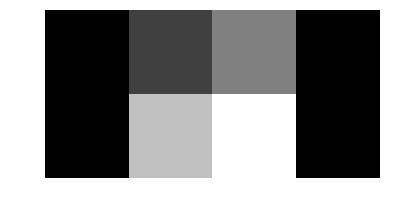

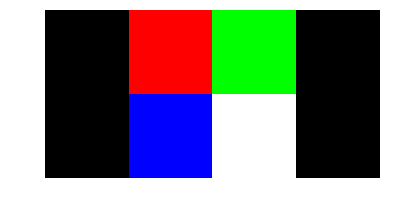

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(imagen, cmap = 'gray')
plt.axis('off')
plt.show()

plt.figure()
plt.imshow(paleta[imagen], cmap = 'gray') #<-- a las imágenes RGB, no les importa el colormap
plt.axis('off')
plt.show()

También podemos proporcionar índices para más de una dimensión. Los arrays de índices para cada dimensión deben tener la misma forma.

In [8]:
A = np.arange(1,26).reshape(5,5)
A

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20],
       [21, 22, 23, 24, 25]])

In [9]:
I = np.array([[0,1],                        # Índices para la primera dimesión de A
              [1,2]])

J = np.array([[2,1],                        # Índices para la segunda dimesión de A
              [3,3]])

A[I,J]                                      # I y J deben tener la misma forma

array([[ 3,  7],
       [ 9, 14]])

In [10]:
A[I,2]

array([[ 3,  8],
       [ 8, 13]])

In [11]:
A[:,J]                      

array([[[ 3,  2],
        [ 4,  4]],

       [[ 8,  7],
        [ 9,  9]],

       [[13, 12],
        [14, 14]],

       [[18, 17],
        [19, 19]],

       [[23, 22],
        [24, 24]]])

Podemos poner I y J en una lista y luego hacer la indexación con la lista

In [12]:
L = [I,J]

A[L]                                       # equivalente a A[I,J]

array([[ 3,  7],
       [ 9, 14]])

Sin embargo, no podemos hacer esto poniendo I y J en un array, ya que este array se interpretará como indexando la primera dimensión de A.

In [ ]:
S = np.array([I,J])

A[S]                                       # No es lo mismo que lo visto arriba

In [ ]:
A[tuple(S)]                                # lo mismo que A[I,J]

También puede usar la indexación para asignar valores a arrays:

In [13]:
A = np.arange(5)
A

array([0, 1, 2, 3, 4])

In [14]:
A[[1,3,4]] = 0
A

array([0, 0, 2, 0, 0])

In [15]:
A = np.arange(5)
A

array([0, 1, 2, 3, 4])

In [16]:
A[[0,3,2]] = [1,2,3]
A

array([1, 1, 3, 2, 4])

Sin embargo, cuando la lista de índices contiene repeticiones, la asignación se realiza varias veces, pisando el último valor:

In [17]:
A = np.arange(5)
A

array([0, 1, 2, 3, 4])

In [18]:
A[[0,0,2]] = [1,2,3]
A

array([2, 1, 3, 3, 4])

### Indexado lógico

In [19]:
A = np.arange(12).reshape(3,4)
B = A > 4

print(A)
print(B)                                          # B es un array lógico de las mismas forma de A

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[False False False False]
 [False  True  True  True]
 [ True  True  True  True]]


Se puede hacer un slicing de los elementos de A que cumplen con la condición dada por B

In [20]:
A[B]                                       # array 1D con los elementos de A donde B es True

array([ 5,  6,  7,  8,  9, 10, 11])

o, en forma equivalente...

In [21]:
A[A > 4]

array([ 5,  6,  7,  8,  9, 10, 11])

También se puede combinar más de una condición:

In [22]:
A[(A > 4) & (A < 9)]

array([5, 6, 7, 8])

Este tipo de slicing especial crea copias, no vistas!

In [23]:
C = A[B]
C[0] = 23
C

array([23,  6,  7,  8,  9, 10, 11])

In [24]:
A  # A sigue igual que antes, como si nada...

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

Esto es muy util para hacer asignaciones basados en un criterio:

In [25]:
A[B] = 0                                   # Esto hace cero todos los elementos de A que son mayores a 4
A

array([[0, 1, 2, 3],
       [4, 0, 0, 0],
       [0, 0, 0, 0]])

Si quisieramos recuperar los índices de donde una array cumple una condición, podemos usar np.where():

In [29]:
D = np.random.random([5])
D

array([ 0.83063776,  0.30407465,  0.36936558,  0.84062321,  0.13644335])

In [30]:
I = np.where(D>0.5)

In [31]:
D[I]

array([ 0.83063776,  0.84062321])

que es equivalente a

In [32]:
D[D>0.5]

array([ 0.83063776,  0.84062321])

### Ejemplo

Como ejemplo, de indexado lógico, trataremos de segmentar el "tejido blando" de un fantoma:

(483, 491)


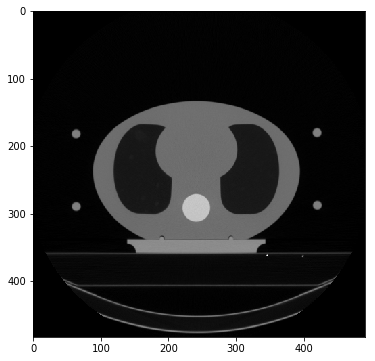

In [36]:
import matplotlib.pyplot as plt

I = plt.imread('./Data/cirs_slice.png')[:,:,0]

print(I.shape)
plt.figure(figsize = (6,6))
plt.imshow(I, cmap = 'gray')
plt.show()

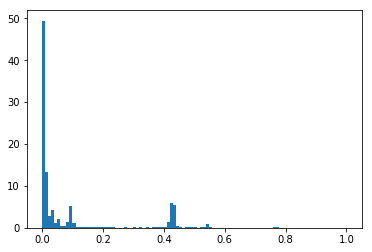

In [37]:
plt.figure()
plt.hist(I.ravel(), bins=100, normed=1)       
plt.show()

In [38]:
Mask = np.zeros(I.shape)

Mask[(I>0.4) & (I<0.45)] = 1 #usar 0.6 y 0.8 para la médula y 0.4 y 0.45 para el tejido blando.¿Y para pulmón?

print(Mask.max())
print(Mask.min())

1.0
0.0


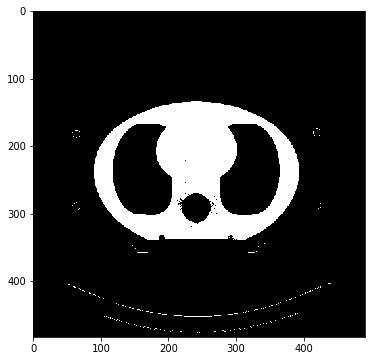

In [39]:
plt.figure(figsize = (6,6))
plt.imshow(Mask, cmap = 'gray')
plt.show()

In [40]:
red_mask = np.dstack([Mask, np.zeros(Mask.shape), np.zeros_like(Mask)])

print(red_mask.shape)

(483, 491, 3)


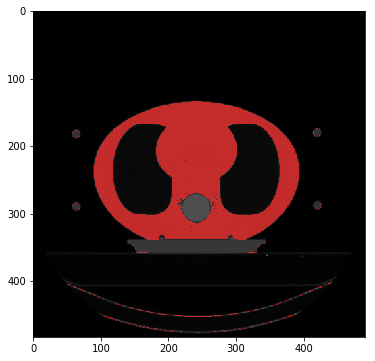

In [43]:

plt.figure(figsize = (6,6))
plt.imshow(I, cmap = 'gray')
plt.imshow(red_mask, alpha = 0.6)
plt.show()


In [56]:
A = np.ones([5,4])
B = np.zeros([5,1])

C = np.hstack([A,B])


D = np.empty([5,5])
D[:,:4] = A
D[:,-1] = B.ravel()
print(C)
print(D)

[[ 1.  1.  1.  1.  0.]
 [ 1.  1.  1.  1.  0.]
 [ 1.  1.  1.  1.  0.]
 [ 1.  1.  1.  1.  0.]
 [ 1.  1.  1.  1.  0.]]
[[ 1.  1.  1.  1.  0.]
 [ 1.  1.  1.  1.  0.]
 [ 1.  1.  1.  1.  0.]
 [ 1.  1.  1.  1.  0.]
 [ 1.  1.  1.  1.  0.]]
